# Patch-MLP-TS: Benchmark, Ablation, Efficiency
Research-grade notebook. Sections:
1. Setup & config
2. Data pipeline
3. Model definitions (Linear, NLinear, DLinear, PatchMLPTS, PatchTST, PatchMLPTS ablation variants)
4. Training / evaluation utilities
5. Main benchmark (ETT x4 + Electricity, multi-seed)
6. Ablation study
7. Efficiency comparison (params / train time / inference time)
8. Final result tables


## 1. Setup & Config

In [2]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
SEED = 42
BATCH_SIZE = 64
ELECTRICITY_BATCH = 16   # smaller batch, C~320 channels heavy in channel-independent reshape
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
LOOKBACK = 96

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print("Seed:", SEED)

Seed: 42


In [5]:
# ---- EDIT THESE PATHS for your environment ----
DATA_DIR = "/kaggle/input/datasets/vedantjadhavv/electricity-data"

DATASETS = {
    "ETTh1": os.path.join(DATA_DIR, "ETTh1.csv"),
    "ETTh2": os.path.join(DATA_DIR, "ETTh2.csv"),
    "ETTm1": os.path.join(DATA_DIR, "ETTm1.csv"),
    "ETTm2": os.path.join(DATA_DIR, "ETTm2.csv"),
    "Electricity": os.path.join(DATA_DIR, "electricity.csv"),
}

for name, path in DATASETS.items():
    print(name, "->", path, "| exists:", os.path.exists(path))

ETTh1 -> /kaggle/input/datasets/vedantjadhavv/electricity-data/ETTh1.csv | exists: True
ETTh2 -> /kaggle/input/datasets/vedantjadhavv/electricity-data/ETTh2.csv | exists: True
ETTm1 -> /kaggle/input/datasets/vedantjadhavv/electricity-data/ETTm1.csv | exists: True
ETTm2 -> /kaggle/input/datasets/vedantjadhavv/electricity-data/ETTm2.csv | exists: True
Electricity -> /kaggle/input/datasets/vedantjadhavv/electricity-data/electricity.csv | exists: True


## 2. Data Pipeline

In [6]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.lookback = lookback
        self.horizon = horizon
        self.length = len(data) - lookback - horizon + 1

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.lookback]
        y = self.data[idx + self.lookback: idx + self.lookback + self.horizon]
        return x, y

In [7]:
def load_dataframe(path):
    df = pd.read_csv(path)
    first_col = df.columns[0]
    try:
        pd.to_datetime(df[first_col])
        df = df.drop(columns=[first_col])
    except Exception:
        pass

    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how="all")
    df = df.interpolate(limit_direction="both")
    return df


def make_dataloaders(path, lookback, horizon, batch_size=64,
                      train_ratio=0.7, val_ratio=0.1, feature_limit=None):
    df = load_dataframe(path)
    if feature_limit is not None:
        df = df.iloc[:, :feature_limit]

    values = df.values.astype(np.float32)
    n = len(values)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_raw = values[:train_end]
    val_raw = values[train_end:val_end]
    test_raw = values[val_end:]

    mean = train_raw.mean(axis=0)
    std = train_raw.std(axis=0)
    std[std < 1e-6] = 1.0

    train_data = (train_raw - mean) / std
    val_data = (val_raw - mean) / std
    test_data = (test_raw - mean) / std

    train_dataset = TimeSeriesWindowDataset(train_data, lookback, horizon)
    val_dataset = TimeSeriesWindowDataset(val_data, lookback, horizon)
    test_dataset = TimeSeriesWindowDataset(test_data, lookback, horizon)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               drop_last=False, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                             drop_last=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              drop_last=False, num_workers=2, pin_memory=True)

    stats = {"mean": mean, "std": std, "num_features": values.shape[1], "total_rows": n}
    return train_loader, val_loader, test_loader, stats

In [8]:
# sanity check
train_loader, val_loader, test_loader, stats = make_dataloaders(
    DATASETS["ETTh1"], lookback=96, horizon=96, batch_size=BATCH_SIZE
)
print("Features:", stats["num_features"])
print("Rows:", stats["total_rows"])
x, y = next(iter(train_loader))
print("X shape:", x.shape)
print("Y shape:", y.shape)

Features: 7
Rows: 17420
X shape: torch.Size([64, 96, 7])
Y shape: torch.Size([64, 96, 7])


## 3. Model Definitions

All channel-independent models reshape `(B, L, C) -> (B*C, L)` for per-channel processing.
**Important:** permute to `(B, C, L)` before reshape — reshaping `(B, L, C)` directly to
`(B*C, L)` silently scrambles data (L and C get mixed since C is the innermost dim). This
was caught and fixed during development — verify any new model follows the same pattern.

In [9]:
class LinearModel(nn.Module):
    """Single shared linear layer across all channels (LTSF-Linear baseline)."""
    def __init__(self, lookback, horizon, num_features):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)

    def forward(self, x):
        # x: [B, L, C]
        x = x.permute(0, 2, 1)      # [B, C, L]
        y = self.linear(x)          # [B, C, H]
        return y.permute(0, 2, 1)   # [B, H, C]


class NLinearModel(nn.Module):
    """Linear + last-value normalization (handles distribution shift)."""
    def __init__(self, lookback, horizon, num_features):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)

    def forward(self, x):
        last = x[:, -1:, :]         # [B, 1, C]
        x = x - last
        x = x.permute(0, 2, 1)      # [B, C, L]
        y = self.linear(x)          # [B, C, H]
        y = y.permute(0, 2, 1)      # [B, H, C]
        return y + last


class DLinearModel(nn.Module):
    """Trend/seasonal decomposition + two linear heads, shared across channels."""
    def __init__(self, lookback, horizon, num_features, moving_avg_kernel=25):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.moving_avg = nn.AvgPool1d(kernel_size=moving_avg_kernel, stride=1,
                                        padding=moving_avg_kernel // 2)
        self.seasonal_linear = nn.Linear(lookback, horizon)
        self.trend_linear = nn.Linear(lookback, horizon)

    def forward(self, x):
        B, L, C = x.shape
        x_bc = x.permute(0, 2, 1).reshape(B * C, L).unsqueeze(1)  # permute BEFORE reshape
        trend = self.moving_avg(x_bc).squeeze(1)
        seasonal = x_bc.squeeze(1) - trend
        seasonal_out = self.seasonal_linear(seasonal)
        trend_out = self.trend_linear(trend)
        pred = (seasonal_out + trend_out).reshape(B, C, self.horizon)
        return pred.permute(0, 2, 1)

In [10]:
class PatchMLPTS(nn.Module):
    """Patch-based, channel-independent all-MLP forecaster (this paper's model)."""
    def __init__(self, lookback, horizon, num_features,
                 patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1

        self.patch_embed = nn.Linear(patch_len, embed_dim)
        self.mlp_blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim),
                nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])
        self.head = nn.Linear(embed_dim, horizon)

    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :]
        x = x.reshape(B, N, P, C)
        x = x.permute(0, 3, 1, 2).reshape(B * C, N, P)  # channel-independent patches
        e = self.patch_embed(x)
        for block in self.mlp_blocks:
            e = e + block(e)
        z = e.mean(dim=1)
        y = self.head(z)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)


class PatchMLPTS_NoPatching(nn.Module):
    """Ablation: same MLP backbone, no patching -- embeds the whole lookback at once."""
    def __init__(self, lookback, horizon, num_features,
                 embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.input_embed = nn.Linear(lookback, embed_dim)
        self.mlp_blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim),
                nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])
        self.head = nn.Linear(embed_dim, horizon)

    def forward(self, x):
        B, L, C = x.shape
        x = x.permute(0, 2, 1).reshape(B * C, L)  # channel-independent, whole series
        e = self.input_embed(x)
        for block in self.mlp_blocks:
            e = e + block(e)
        y = self.head(e)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)


class PatchMLPTS_ChannelMixing(nn.Module):
    """Ablation: same patching/MLP backbone, but channels mixed into each patch token
    instead of processed independently."""
    def __init__(self, lookback, horizon, num_features,
                 patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.num_features = num_features
        self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1

        self.patch_embed = nn.Linear(patch_len * num_features, embed_dim)
        self.mlp_blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim),
                nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])
        self.head = nn.Linear(embed_dim, horizon * num_features)

    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :]
        x = x.reshape(B, N, P, C)
        x = x.reshape(B, N, P * C)          # channels mixed into patch token
        e = self.patch_embed(x)
        for block in self.mlp_blocks:
            e = e + block(e)
        z = e.mean(dim=1)
        y = self.head(z)
        return y.reshape(B, self.horizon, C)

In [11]:
class PatchTST(nn.Module):
    """Channel-independent patched Transformer encoder (Nie et al., 2023) --
    used here as the attention-based comparison point for PatchMLPTS."""
    def __init__(self, lookback, horizon, num_features,
                 patch_len=16, stride=8, d_model=128, n_heads=8,
                 num_layers=2, dropout=0.1, d_ff=256):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = (lookback - patch_len) // stride + 2  # +1 padded patch

        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(self.num_patches * d_model, horizon)

    def forward(self, x):
        B, L, C = x.shape
        x = x.permute(0, 2, 1)                      # [B, C, L]
        pad = x[:, :, -1:].repeat(1, 1, self.stride)  # replicate-pad last value
        x = torch.cat([x, pad], dim=-1)              # [B, C, L+stride]
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)  # [B, C, N, P]
        x = x.reshape(B * C, self.num_patches, self.patch_len)
        e = self.patch_embed(x) + self.pos_embed
        e = self.encoder(e)
        e = e.reshape(B * C, -1)
        y = self.head(e)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


MAIN_MODELS = ["Linear", "NLinear", "DLinear", "PatchMLPTS", "PatchTST"]


def create_model(name, lookback, horizon, num_features):
    if name == "Linear":
        return LinearModel(lookback, horizon, num_features)
    if name == "NLinear":
        return NLinearModel(lookback, horizon, num_features)
    if name == "DLinear":
        return DLinearModel(lookback, horizon, num_features, moving_avg_kernel=25)
    if name == "PatchMLPTS":
        return PatchMLPTS(lookback, horizon, num_features,
                           patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_NoPatching":
        return PatchMLPTS_NoPatching(lookback, horizon, num_features,
                                      embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_ChannelMixing":
        return PatchMLPTS_ChannelMixing(lookback, horizon, num_features,
                                         patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchTST":
        return PatchTST(lookback, horizon, num_features,
                         patch_len=16, stride=8, d_model=128, n_heads=8,
                         num_layers=2, dropout=0.1)
    raise ValueError(f"unknown model: {name}")

## 4. Training / Evaluation Utilities

In [13]:
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = 0.0; self.count = 0
    def update(self, val, n=1): self.sum += val * n; self.count += n
    def avg(self): return self.sum / self.count if self.count > 0 else 0.0


def fit_model(model, train_loader, val_loader, test_loader,
              epochs=20, lr=1e-3, weight_decay=1e-4, patience=5,
              device="cuda", verbose=True):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(patience // 2, 1)
    )

    best_val = float("inf")
    best_state = None
    patience_counter = 0
    history = {"train_mse": [], "val_mse": []}

    for epoch in range(epochs):
        model.train()
        train_meter = AverageMeter()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_meter.update(loss.item(), x.size(0))

        model.eval()
        val_meter = AverageMeter()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                val_meter.update(F.mse_loss(pred, y).item(), x.size(0))

        train_mse, val_mse = train_meter.avg(), val_meter.avg()
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        scheduler.step(val_mse)

        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose:
            print(f"epoch {epoch+1:02d} | train {train_mse:.6f} | val {val_mse:.6f}")
        if patience_counter >= patience:
            if verbose: print("early stop")
            break

    model.load_state_dict(best_state)
    model.eval()
    test_mse_meter, test_mae_meter = AverageMeter(), AverageMeter()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_mse_meter.update(F.mse_loss(pred, y).item(), x.size(0))
            test_mae_meter.update(F.l1_loss(pred, y).item(), x.size(0))

    return model, test_mse_meter.avg(), test_mae_meter.avg(), history

In [16]:
def measure_epoch_time(model, loader, device, optimizer, n_epochs=3):
    model.train()
    criterion = nn.MSELoss()
    times = []
    for _ in range(n_epochs):
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
        if device.type == "cuda": torch.cuda.synchronize()
        times.append(time.time() - t0)
    return sum(times) / len(times)


def measure_inference_time(model, loader, device, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= n_batches:
                break
            x = x.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.time()
            _ = model(x)
            if device.type == "cuda": torch.cuda.synchronize()
            times.append(time.time() - t0)
    return (sum(times) / len(times)) * 1000  # ms/batch

## 5. Main Benchmark (ETT x4 + Electricity)

In [14]:
ETT_DATASETS = ["ETTh1", "ETTh2", "ETTm1", "ETTm2"]
HORIZONS = [96, 192, 336, 720]

results = []

for dataset_name in ETT_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        print("\n" + "=" * 70)
        print(f"{dataset_name} | horizon={horizon}")
        print("=" * 70)

        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=BATCH_SIZE
        )
        num_features = stats["num_features"]

        for model_name in MAIN_MODELS:
            print(f"\n--- {model_name} ---")
            seed_everything(SEED)
            model = create_model(model_name, LOOKBACK, horizon, num_features)
            params = count_parameters(model)

            model, test_mse, test_mae, history = fit_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, verbose=False
            )

            print(f"{model_name}: MSE={test_mse:.4f} MAE={test_mae:.4f} params={params:,}")

            results.append({
                "seed": SEED, "dataset": dataset_name, "lookback": LOOKBACK,
                "horizon": horizon, "model": model_name,
                "parameters": params, "MSE": test_mse, "MAE": test_mae
            })

            del model
            torch.cuda.empty_cache()

df_ett_results = pd.DataFrame(results)
df_ett_results.to_csv("ett_benchmark_results.csv", index=False)
print("\nSaved ett_benchmark_results.csv")
df_ett_results


ETTh1 | horizon=96

--- Linear ---
Linear: MSE=0.4415 MAE=0.4458 params=9,312

--- NLinear ---
NLinear: MSE=0.4463 MAE=0.4492 params=9,312

--- DLinear ---
DLinear: MSE=0.4410 MAE=0.4456 params=18,624

--- PatchMLPTS ---
PatchMLPTS: MSE=0.8141 MAE=0.6481 params=409,952

--- PatchTST ---
PatchTST: MSE=0.4286 MAE=0.4516 params=416,224

ETTh1 | horizon=192

--- Linear ---
Linear: MSE=0.4928 MAE=0.4847 params=18,624

--- NLinear ---
NLinear: MSE=0.5059 MAE=0.4896 params=18,624

--- DLinear ---
DLinear: MSE=0.4900 MAE=0.4825 params=37,248

--- PatchMLPTS ---
PatchMLPTS: MSE=0.8580 MAE=0.6727 params=422,336

--- PatchTST ---
PatchTST: MSE=0.4720 MAE=0.4824 params=563,776

ETTh1 | horizon=336

--- Linear ---
Linear: MSE=0.5365 MAE=0.5188 params=32,592

--- NLinear ---
NLinear: MSE=0.5503 MAE=0.5178 params=32,592

--- DLinear ---
DLinear: MSE=0.5354 MAE=0.5179 params=65,184

--- PatchMLPTS ---
PatchMLPTS: MSE=0.8981 MAE=0.6920 params=440,912

--- PatchTST ---
PatchTST: MSE=0.5360 MAE=0.5283 p

,seed,dataset,lookback,horizon,model,parameters,MSE,MAE
0,42,ETTh1,96,96,Linear,9312,0.441514,0.445779
1,42,ETTh1,96,96,NLinear,9312,0.446259,0.449240
2,42,ETTh1,96,96,DLinear,18624,0.441025,0.445583
3,42,ETTh1,96,96,PatchMLPTS,409952,0.814089,0.648072
4,42,ETTh1,96,96,PatchTST,416224,0.428594,0.451565
...,...,...,...,...,...,...,...,...
75,42,ETTm2,96,720,Linear,69840,0.227377,0.328480
76,42,ETTm2,96,720,NLinear,69840,0.238323,0.328228
77,42,ETTm2,96,720,DLinear,139680,0.226223,0.327033
78,42,ETTm2,96,720,PatchMLPTS,490448,0.255815,0.357439


In [15]:
ELECTRICITY_HORIZONS = [96, 720]  # 336/192 optional -- add to list if time allows

electricity_results = []
path = DATASETS["Electricity"]

for horizon in ELECTRICITY_HORIZONS:
    print("\n" + "=" * 70)
    print(f"Electricity | horizon={horizon}")
    print("=" * 70)

    train_loader, val_loader, test_loader, stats = make_dataloaders(
        path, lookback=LOOKBACK, horizon=horizon, batch_size=ELECTRICITY_BATCH
    )
    num_features = stats["num_features"]

    for model_name in MAIN_MODELS:
        print(f"\n--- {model_name} ---")
        seed_everything(SEED)
        model = create_model(model_name, LOOKBACK, horizon, num_features)
        params = count_parameters(model)

        model, test_mse, test_mae, history = fit_model(
            model, train_loader, val_loader, test_loader,
            epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
            patience=PATIENCE, device=DEVICE, verbose=False
        )

        print(f"{model_name}: MSE={test_mse:.4f} MAE={test_mae:.4f} params={params:,}")

        electricity_results.append({
            "seed": SEED, "dataset": "Electricity", "lookback": LOOKBACK,
            "horizon": horizon, "model": model_name,
            "parameters": params, "MSE": test_mse, "MAE": test_mae
        })

        del model
        torch.cuda.empty_cache()

df_electricity = pd.DataFrame(electricity_results)
df_electricity.to_csv("electricity_benchmark_results.csv", index=False)
print("\nSaved electricity_benchmark_results.csv")
df_electricity


Electricity | horizon=96

--- Linear ---
Linear: MSE=0.1955 MAE=0.2779 params=9,312

--- NLinear ---
NLinear: MSE=0.1985 MAE=0.2751 params=9,312

--- DLinear ---
DLinear: MSE=0.1960 MAE=0.2781 params=18,624

--- PatchMLPTS ---
PatchMLPTS: MSE=0.7522 MAE=0.7166 params=409,952

--- PatchTST ---
PatchTST: MSE=0.1630 MAE=0.2514 params=416,224

Electricity | horizon=720

--- Linear ---
Linear: MSE=0.2424 MAE=0.3287 params=69,840

--- NLinear ---
NLinear: MSE=0.2531 MAE=0.3249 params=69,840

--- DLinear ---
DLinear: MSE=0.2414 MAE=0.3261 params=139,680

--- PatchMLPTS ---
PatchMLPTS: MSE=0.7958 MAE=0.7348 params=490,448

--- PatchTST ---
PatchTST: MSE=0.2296 MAE=0.3135 params=1,375,312

Saved electricity_benchmark_results.csv


,seed,dataset,lookback,horizon,model,parameters,MSE,MAE
0,42,Electricity,96,96,Linear,9312,0.195541,0.277867
1,42,Electricity,96,96,NLinear,9312,0.198472,0.275092
2,42,Electricity,96,96,DLinear,18624,0.196043,0.278115
3,42,Electricity,96,96,PatchMLPTS,409952,0.752234,0.716621
4,42,Electricity,96,96,PatchTST,416224,0.163033,0.251381
5,42,Electricity,96,720,Linear,69840,0.242365,0.328723
6,42,Electricity,96,720,NLinear,69840,0.253054,0.324863
7,42,Electricity,96,720,DLinear,139680,0.241383,0.326141
8,42,Electricity,96,720,PatchMLPTS,490448,0.795801,0.734770
9,42,Electricity,96,720,PatchTST,1375312,0.229562,0.313527


### Multi-seed runs (optional, expensive)
Reruns the same grid with different seeds so the final table can report mean +/- std.
Scoped to H=96/720 only to keep runtime reasonable -- widen `GRID_HORIZONS` if you have budget.

In [ ]:
def run_full_grid(dataset_names, horizons, model_names, seeds,
                   batch_size=BATCH_SIZE, epochs=EPOCHS):
    all_results = []
    for seed in seeds:
        for dataset_name in dataset_names:
            path = DATASETS[dataset_name]
            bs = ELECTRICITY_BATCH if dataset_name == "Electricity" else batch_size
            for horizon in horizons:
                train_loader, val_loader, test_loader, stats = make_dataloaders(
                    path, lookback=LOOKBACK, horizon=horizon, batch_size=bs
                )
                num_features = stats["num_features"]
                for model_name in model_names:
                    seed_everything(seed)
                    model = create_model(model_name, LOOKBACK, horizon, num_features)
                    params = count_parameters(model)
                    model, test_mse, test_mae, history = fit_model(
                        model, train_loader, val_loader, test_loader,
                        epochs=epochs, lr=LR, weight_decay=WEIGHT_DECAY,
                        patience=PATIENCE, device=DEVICE, verbose=False
                    )
                    print(f"seed={seed} {dataset_name} H={horizon} {model_name}: MSE={test_mse:.4f}")
                    all_results.append({
                        "seed": seed, "dataset": dataset_name, "lookback": LOOKBACK,
                        "horizon": horizon, "model": model_name,
                        "parameters": params, "MSE": test_mse, "MAE": test_mae
                    })
                    del model
                    torch.cuda.empty_cache()
    return pd.DataFrame(all_results)

In [ ]:
# EXTRA_SEEDS = [43, 44]
# GRID_DATASETS = ["ETTh1", "ETTh2", "ETTm1", "ETTm2", "Electricity"]
# GRID_HORIZONS = [96, 720]
#
# df_extra_seeds = run_full_grid(GRID_DATASETS, GRID_HORIZONS, MAIN_MODELS, EXTRA_SEEDS)
# df_extra_seeds.to_csv("multiseed_extra_results.csv", index=False)
# df_extra_seeds

# Uncomment above to run seeds 43/44. Skipped by default -- heavy (100 fits).

In [ ]:
def summarize_seeds(df):
    return df.groupby(["dataset", "horizon", "model"]).agg(
        MSE_mean=("MSE", "mean"), MSE_std=("MSE", "std"),
        MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
        parameters=("parameters", "first"),
        n_seeds=("MSE", "count")
    ).reset_index()


# combine whatever seed runs exist so far (works with 1 seed too -- std will be NaN)
df_h96_720 = pd.concat([
    df_ett_results[df_ett_results["horizon"].isin([96, 720])],
    df_electricity
], ignore_index=True)

# if you ran the multi-seed cell above, uncomment:
# df_h96_720 = pd.concat([df_h96_720, df_extra_seeds], ignore_index=True)

df_main_summary = summarize_seeds(df_h96_720)
df_main_summary.to_csv("main_benchmark_summary.csv", index=False)
df_main_summary

## 6. Ablation Study
Full PatchMLPTS vs. no-patching vs. channel-mixing variants.

In [16]:
ABLATION_DATASETS = ["ETTh1", "ETTh2"]
ABLATION_MODELS = ["PatchMLPTS", "PatchMLPTS_NoPatching", "PatchMLPTS_ChannelMixing"]

ablation_results = []

for dataset_name in ABLATION_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        print("\n" + "=" * 70)
        print(f"ABLATION | {dataset_name} | H={horizon}")
        print("=" * 70)

        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=BATCH_SIZE
        )
        C = stats["num_features"]

        for model_name in ABLATION_MODELS:
            print(f"\n--- {model_name} ---")
            seed_everything(SEED)
            model = create_model(model_name, LOOKBACK, horizon, C)
            params = count_parameters(model)

            model, test_mse, test_mae, history = fit_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, verbose=False
            )

            print(f"MSE={test_mse:.4f} MAE={test_mae:.4f}")

            ablation_results.append({
                "dataset": dataset_name, "lookback": LOOKBACK, "horizon": horizon,
                "model": model_name, "parameters": params, "MSE": test_mse, "MAE": test_mae
            })

            del model
            torch.cuda.empty_cache()

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv("patchmlpts_ablation_results.csv", index=False)
print("\nSaved patchmlpts_ablation_results.csv")
df_ablation


ABLATION | ETTh1 | H=96

--- PatchMLPTS ---
MSE=0.8141 MAE=0.6481

--- PatchMLPTS_NoPatching ---
MSE=0.4246 MAE=0.4493

--- PatchMLPTS_ChannelMixing ---
MSE=0.9221 MAE=0.7104

ABLATION | ETTh1 | H=192

--- PatchMLPTS ---
MSE=0.8580 MAE=0.6727

--- PatchMLPTS_NoPatching ---
MSE=0.4748 MAE=0.4871

--- PatchMLPTS_ChannelMixing ---
MSE=1.1063 MAE=0.7812

ABLATION | ETTh1 | H=336

--- PatchMLPTS ---
MSE=0.8981 MAE=0.6920

--- PatchMLPTS_NoPatching ---
MSE=0.5154 MAE=0.5182

--- PatchMLPTS_ChannelMixing ---
MSE=1.1562 MAE=0.8002

ABLATION | ETTh1 | H=720

--- PatchMLPTS ---
MSE=0.9993 MAE=0.7440

--- PatchMLPTS_NoPatching ---
MSE=0.6698 MAE=0.6107

--- PatchMLPTS_ChannelMixing ---
MSE=1.2153 MAE=0.8375

ABLATION | ETTh2 | H=96

--- PatchMLPTS ---
MSE=0.2097 MAE=0.3228

--- PatchMLPTS_NoPatching ---
MSE=0.1730 MAE=0.2846

--- PatchMLPTS_ChannelMixing ---
MSE=0.3744 MAE=0.4727

ABLATION | ETTh2 | H=192

--- PatchMLPTS ---
MSE=0.2562 MAE=0.3595

--- PatchMLPTS_NoPatching ---
MSE=0.2187 MAE=0.3

,dataset,lookback,horizon,model,parameters,MSE,MAE
0,ETTh1,96,96,PatchMLPTS,409952,0.814089,0.648072
1,ETTh1,96,96,PatchMLPTS_NoPatching,420704,0.424593,0.449313
2,ETTh1,96,96,PatchMLPTS_ChannelMixing,493472,0.922089,0.710385
3,ETTh1,96,192,PatchMLPTS,422336,0.857983,0.672664
4,ETTh1,96,192,PatchMLPTS_NoPatching,433088,0.474799,0.487072
5,ETTh1,96,192,PatchMLPTS_ChannelMixing,580160,1.106279,0.781211
6,ETTh1,96,336,PatchMLPTS,440912,0.898082,0.691974
7,ETTh1,96,336,PatchMLPTS_NoPatching,451664,0.515430,0.518211
8,ETTh1,96,336,PatchMLPTS_ChannelMixing,710192,1.156191,0.800236
9,ETTh1,96,720,PatchMLPTS,490448,0.999290,0.744049


In [17]:
ablation_pivot = df_ablation.pivot_table(
    index=["dataset", "horizon"], columns="model", values=["MSE", "MAE"]
)
ablation_pivot.to_csv("ablation_summary_table.csv")
ablation_pivot

MAE                                                 \
model           PatchMLPTS PatchMLPTS_ChannelMixing PatchMLPTS_NoPatching   
dataset horizon                                                             
ETTh1   96        0.648072                 0.710385              0.449313   
        192       0.672664                 0.781211              0.487072   
        336       0.691974                 0.800236              0.518211   
        720       0.744049                 0.837527              0.610686   
ETTh2   96        0.322783                 0.472683              0.284558   
        192       0.359470                 0.517073              0.325383   
        336       0.353268                 0.548606              0.327068   
        720       0.382491                 0.672755              0.368909   

                       MSE                                                 
model           PatchMLPTS PatchMLPTS_ChannelMixing PatchMLPTS_NoPatching  
dataset horizon                                                            
ETTh1   96        0.814089                 0.922089              0.424593  
        192       0.857983                 1.106279              0.474799  
        336       0.898082                 1.156191              0.515430  
        720       0.999290                 1.215307              0.669829  
ETTh2   96        0.209741                 0.374414              0.173018  
        192       0.256162                 0.527917              0.218663  
        336       0.242412                 0.525276              0.216410  
        720       0.278367                 0.758989              0.260609

## 7. Efficiency Comparison: PatchMLPTS vs PatchTST
Params, training time per epoch, inference latency -- on a small-channel dataset (ETTh1)
and a large-channel dataset (Electricity) to show how each scales with C.

In [18]:
efficiency_results = []
EFF_DATASETS = ["ETTh1", "Electricity"]
EFF_HORIZON = 96
EFF_MODELS = ["PatchMLPTS", "PatchTST"]

for dataset_name in EFF_DATASETS:
    path = DATASETS[dataset_name]
    batch = ELECTRICITY_BATCH if dataset_name == "Electricity" else BATCH_SIZE
    train_loader, val_loader, test_loader, stats = make_dataloaders(
        path, lookback=LOOKBACK, horizon=EFF_HORIZON, batch_size=batch
    )
    num_features = stats["num_features"]

    for model_name in EFF_MODELS:
        seed_everything(SEED)
        model = create_model(model_name, LOOKBACK, EFF_HORIZON, num_features).to(DEVICE)
        params = count_parameters(model)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        epoch_time = measure_epoch_time(model, train_loader, DEVICE, optimizer, n_epochs=3)
        inf_time = measure_inference_time(model, test_loader, DEVICE, n_batches=20)

        print(f"{dataset_name} | {model_name}: params={params:,} "
              f"epoch_time={epoch_time:.2f}s inference={inf_time:.2f}ms/batch")

        efficiency_results.append({
            "dataset": dataset_name, "model": model_name, "parameters": params,
            "epoch_time_sec": epoch_time, "inference_ms_per_batch": inf_time
        })
        del model
        torch.cuda.empty_cache()

df_efficiency = pd.DataFrame(efficiency_results)
df_efficiency.to_csv("efficiency_results.csv", index=False)
df_efficiency

ETTh1 | PatchMLPTS: params=409,952 epoch_time=1.14s inference=2.55ms/batch
ETTh1 | PatchTST: params=416,224 epoch_time=2.53s inference=3.14ms/batch
Electricity | PatchMLPTS: params=409,952 epoch_time=54.47s inference=14.19ms/batch
Electricity | PatchTST: params=416,224 epoch_time=161.74s inference=32.21ms/batch


,dataset,model,parameters,epoch_time_sec,inference_ms_per_batch
0,ETTh1,PatchMLPTS,409952,1.138938,2.547812
1,ETTh1,PatchTST,416224,2.525151,3.136277
2,Electricity,PatchMLPTS,409952,54.469595,14.187944
3,Electricity,PatchTST,416224,161.744974,32.206142


In [22]:
class PatchMLPTS_v2(nn.Module):
    """Fix: adds patch positional embedding + cross-patch (token) mixing.
    v1 had neither -- patches processed independently, blindly mean-pooled,
    destroying temporal order. This is the suspected root cause of v1 failure."""
    def __init__(self, lookback, horizon, num_features,
                 patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1
        N = self.num_patches

        self.patch_embed = nn.Linear(patch_len, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, N, embed_dim))

        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(nn.ModuleDict({
                "token_norm": nn.LayerNorm(embed_dim),
                "token_mlp": nn.Sequential(
                    nn.Linear(N, N * 2), nn.GELU(), nn.Dropout(dropout),
                    nn.Linear(N * 2, N), nn.Dropout(dropout),
                ),
                "feat_mix": nn.Sequential(
                    nn.LayerNorm(embed_dim),
                    nn.Linear(embed_dim, embed_dim * 4), nn.GELU(), nn.Dropout(dropout),
                    nn.Linear(embed_dim * 4, embed_dim), nn.Dropout(dropout),
                ),
            }))

        self.final_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(N * embed_dim, horizon)

    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :]
        x = x.reshape(B, N, P, C).permute(0, 3, 1, 2).reshape(B * C, N, P)

        e = self.patch_embed(x) + self.pos_embed  # [B*C, N, d]

        for blk in self.blocks:
            t = blk["token_norm"](e)
            t = t.transpose(1, 2)          # [B*C, d, N]
            t = blk["token_mlp"](t)        # mix across patches
            t = t.transpose(1, 2)          # [B*C, N, d]
            e = e + t
            e = e + blk["feat_mix"](e)

        e = self.final_norm(e)
        z = e.reshape(B * C, -1)
        y = self.head(z)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)

In [23]:
def create_model(name, lookback, horizon, num_features):
    if name == "Linear":
        return LinearModel(lookback, horizon, num_features)
    if name == "NLinear":
        return NLinearModel(lookback, horizon, num_features)
    if name == "DLinear":
        return DLinearModel(lookback, horizon, num_features, moving_avg_kernel=25)
    if name == "PatchMLPTS":
        return PatchMLPTS(lookback, horizon, num_features,
                           patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_v2":
        return PatchMLPTS_v2(lookback, horizon, num_features,
                              patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_NoPatching":
        return PatchMLPTS_NoPatching(lookback, horizon, num_features,
                                      embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_ChannelMixing":
        return PatchMLPTS_ChannelMixing(lookback, horizon, num_features,
                                         patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchTST":
        return PatchTST(lookback, horizon, num_features,
                         patch_len=16, stride=8, d_model=128, n_heads=8,
                         num_layers=2, dropout=0.1)
    raise ValueError(f"unknown model: {name}")

MAIN_MODELS_V2 = ["Linear", "NLinear", "DLinear", "PatchMLPTS_v2", "PatchTST"]

In [24]:
VALIDATE_DATASETS = ["ETTh1", "ETTh2"]
validate_results = []

for dataset_name in VALIDATE_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=BATCH_SIZE
        )
        num_features = stats["num_features"]

        for model_name in MAIN_MODELS_V2:
            seed_everything(SEED)
            model = create_model(model_name, LOOKBACK, horizon, num_features)
            params = count_parameters(model)
            model, test_mse, test_mae, history = fit_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, verbose=False
            )
            print(f"{dataset_name} H={horizon} {model_name}: MSE={test_mse:.4f} MAE={test_mae:.4f}")
            validate_results.append({
                "dataset": dataset_name, "horizon": horizon, "model": model_name,
                "parameters": params, "MSE": test_mse, "MAE": test_mae
            })
            del model
            torch.cuda.empty_cache()

df_validate = pd.DataFrame(validate_results)
df_validate.to_csv("v2_validation_results.csv", index=False)
df_validate.pivot_table(index=["dataset","horizon"], columns="model", values="MSE")

ETTh1 H=96 Linear: MSE=0.4415 MAE=0.4458
ETTh1 H=96 NLinear: MSE=0.4463 MAE=0.4492
ETTh1 H=96 DLinear: MSE=0.4410 MAE=0.4456
ETTh1 H=96 PatchMLPTS_v2: MSE=0.4178 MAE=0.4453
ETTh1 H=96 PatchTST: MSE=0.4286 MAE=0.4516
ETTh1 H=192 Linear: MSE=0.4928 MAE=0.4847
ETTh1 H=192 NLinear: MSE=0.5059 MAE=0.4896
ETTh1 H=192 DLinear: MSE=0.4900 MAE=0.4825
ETTh1 H=192 PatchMLPTS_v2: MSE=0.4689 MAE=0.4830
ETTh1 H=192 PatchTST: MSE=0.4720 MAE=0.4824
ETTh1 H=336 Linear: MSE=0.5365 MAE=0.5188
ETTh1 H=336 NLinear: MSE=0.5503 MAE=0.5178
ETTh1 H=336 DLinear: MSE=0.5354 MAE=0.5179
ETTh1 H=336 PatchMLPTS_v2: MSE=0.5273 MAE=0.5165
ETTh1 H=336 PatchTST: MSE=0.5360 MAE=0.5283
ETTh1 H=720 Linear: MSE=0.6577 MAE=0.5991
ETTh1 H=720 NLinear: MSE=0.7076 MAE=0.6118
ETTh1 H=720 DLinear: MSE=0.6515 MAE=0.5944
ETTh1 H=720 PatchMLPTS_v2: MSE=0.6498 MAE=0.5958
ETTh1 H=720 PatchTST: MSE=0.6275 MAE=0.5932
ETTh2 H=96 Linear: MSE=0.1684 MAE=0.2820
ETTh2 H=96 NLinear: MSE=0.1741 MAE=0.2841
ETTh2 H=96 DLinear: MSE=0.1704 MAE=0.2

model             DLinear    Linear   NLinear  PatchMLPTS_v2  PatchTST
dataset horizon                                                       
ETTh1   96       0.441025  0.441514  0.446259       0.417808  0.428594
        192      0.490017  0.492821  0.505943       0.468896  0.471991
        336      0.535380  0.536480  0.550331       0.527324  0.535977
        720      0.651528  0.657679  0.707585       0.649806  0.627515
ETTh2   96       0.170391  0.168415  0.174145       0.172744  0.181988
        192      0.193751  0.194048  0.203466       0.208906  0.223787
        336      0.212947  0.213473  0.230542       0.221058  0.261513
        720      0.266631  0.262850  0.298021       0.284858  0.284024

In [25]:
pivot = df_validate.pivot_table(index=["dataset","horizon"], columns="model", values="MSE")
v2_rank = pivot.rank(axis=1)["PatchMLPTS_v2"]
print("v2 rank per row (1=best, 5=worst):")
print(v2_rank)
print("\nv2 avg rank:", v2_rank.mean())
print("v2 avg MSE:", pivot["PatchMLPTS_v2"].mean())
print("DLinear avg MSE (baseline to beat):", pivot["DLinear"].mean())

v2 rank per row (1=best, 5=worst):
dataset  horizon
ETTh1    96         1.0
         192        1.0
         336        1.0
         720        2.0
ETTh2    96         3.0
         192        4.0
         336        3.0
         720        4.0
Name: PatchMLPTS_v2, dtype: float64

v2 avg rank: 2.375
v2 avg MSE: 0.36892509504457355
DLinear avg MSE (baseline to beat): 0.3702088427986433


In [26]:
class PatchMLPTS_v2_NoPatching(nn.Module):
    """v2 backbone (token-mix + feat-mix + pos-embed logic) but no patch split --
    single 'patch' = whole lookback. Tests whether patching+mixing beats no-patching
    now that v2 has the cross-patch mixing v1 lacked."""
    def __init__(self, lookback, horizon, num_features, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.embed = nn.Linear(lookback, embed_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim * 4), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim), nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])
        self.head = nn.Linear(embed_dim, horizon)

    def forward(self, x):
        B, L, C = x.shape
        x = x.permute(0, 2, 1).reshape(B * C, L)
        e = self.embed(x)
        for block in self.blocks:
            e = e + block(e)
        y = self.head(e)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)


def create_model_v2(name, lookback, horizon, num_features):
    if name == "PatchMLPTS_v2":
        return PatchMLPTS_v2(lookback, horizon, num_features,
                              patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_v2_NoPatching":
        return PatchMLPTS_v2_NoPatching(lookback, horizon, num_features,
                                         embed_dim=128, num_blocks=3, dropout=0.1)
    return create_model(name, lookback, horizon, num_features)


ABLATION_V2_DATASETS = ["ETTh1", "ETTh2"]
ABLATION_V2_MODELS = ["PatchMLPTS_v2", "PatchMLPTS_v2_NoPatching"]
ablation_v2_results = []

for dataset_name in ABLATION_V2_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=BATCH_SIZE
        )
        C = stats["num_features"]
        for model_name in ABLATION_V2_MODELS:
            seed_everything(SEED)
            model = create_model_v2(model_name, LOOKBACK, horizon, C)
            model, test_mse, test_mae, history = fit_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, verbose=False
            )
            print(f"{dataset_name} H={horizon} {model_name}: MSE={test_mse:.4f}")
            ablation_v2_results.append({
                "dataset": dataset_name, "horizon": horizon, "model": model_name,
                "MSE": test_mse, "MAE": test_mae
            })
            del model
            torch.cuda.empty_cache()

df_ablation_v2 = pd.DataFrame(ablation_v2_results)
df_ablation_v2.to_csv("ablation_v2_results.csv", index=False)
df_ablation_v2.pivot_table(index=["dataset","horizon"], columns="model", values="MSE")

ETTh1 H=96 PatchMLPTS_v2: MSE=0.4178
ETTh1 H=96 PatchMLPTS_v2_NoPatching: MSE=0.4246
ETTh1 H=192 PatchMLPTS_v2: MSE=0.4689
ETTh1 H=192 PatchMLPTS_v2_NoPatching: MSE=0.4748
ETTh1 H=336 PatchMLPTS_v2: MSE=0.5273
ETTh1 H=336 PatchMLPTS_v2_NoPatching: MSE=0.5154
ETTh1 H=720 PatchMLPTS_v2: MSE=0.6498
ETTh1 H=720 PatchMLPTS_v2_NoPatching: MSE=0.6698
ETTh2 H=96 PatchMLPTS_v2: MSE=0.1727
ETTh2 H=96 PatchMLPTS_v2_NoPatching: MSE=0.1730
ETTh2 H=192 PatchMLPTS_v2: MSE=0.2089
ETTh2 H=192 PatchMLPTS_v2_NoPatching: MSE=0.2187
ETTh2 H=336 PatchMLPTS_v2: MSE=0.2211
ETTh2 H=336 PatchMLPTS_v2_NoPatching: MSE=0.2164
ETTh2 H=720 PatchMLPTS_v2: MSE=0.2849
ETTh2 H=720 PatchMLPTS_v2_NoPatching: MSE=0.2606


model            PatchMLPTS_v2  PatchMLPTS_v2_NoPatching
dataset horizon                                         
ETTh1   96            0.417808                  0.424593
        192           0.468896                  0.474799
        336           0.527324                  0.515430
        720           0.649806                  0.669829
ETTh2   96            0.172744                  0.173018
        192           0.208906                  0.218663
        336           0.221058                  0.216410
        720           0.284858                  0.260609

In [27]:
ELECTRICITY_HORIZONS = [96, 720]
elec_v2_results = []
path = DATASETS["Electricity"]

for horizon in ELECTRICITY_HORIZONS:
    train_loader, val_loader, test_loader, stats = make_dataloaders(
        path, lookback=LOOKBACK, horizon=horizon, batch_size=ELECTRICITY_BATCH
    )
    num_features = stats["num_features"]
    for model_name in MAIN_MODELS_V2:
        seed_everything(SEED)
        model = create_model(model_name, LOOKBACK, horizon, num_features)
        params = count_parameters(model)
        model, test_mse, test_mae, history = fit_model(
            model, train_loader, val_loader, test_loader,
            epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
            patience=PATIENCE, device=DEVICE, verbose=False
        )
        print(f"Electricity H={horizon} {model_name}: MSE={test_mse:.4f} MAE={test_mae:.4f} params={params:,}")
        elec_v2_results.append({
            "dataset": "Electricity", "horizon": horizon, "model": model_name,
            "parameters": params, "MSE": test_mse, "MAE": test_mae
        })
        del model
        torch.cuda.empty_cache()

df_elec_v2 = pd.DataFrame(elec_v2_results)
df_elec_v2.to_csv("electricity_v2_results.csv", index=False)
df_elec_v2.pivot_table(index="horizon", columns="model", values="MSE")

Electricity H=96 Linear: MSE=0.1955 MAE=0.2779 params=9,312
Electricity H=96 NLinear: MSE=0.1985 MAE=0.2751 params=9,312
Electricity H=96 DLinear: MSE=0.1960 MAE=0.2781 params=18,624
Electricity H=96 PatchMLPTS_v2: MSE=0.1613 MAE=0.2500 params=498,856
Electricity H=96 PatchTST: MSE=0.1630 MAE=0.2514 params=416,224
Electricity H=720 Linear: MSE=0.2424 MAE=0.3287 params=69,840
Electricity H=720 NLinear: MSE=0.2531 MAE=0.3249 params=69,840
Electricity H=720 DLinear: MSE=0.2414 MAE=0.3261 params=139,680
Electricity H=720 PatchMLPTS_v2: MSE=0.2225 MAE=0.3103 params=1,138,456
Electricity H=720 PatchTST: MSE=0.2296 MAE=0.3135 params=1,375,312


model,DLinear,Linear,NLinear,PatchMLPTS_v2,PatchTST
horizon,,,,,
96,0.196043,0.195541,0.198472,0.161251,0.163033
720,0.241383,0.242365,0.253054,0.222472,0.229562


In [1]:
import os, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

SEED = 42
BATCH_SIZE = 64
ELECTRICITY_BATCH = 16
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
LOOKBACK = 96
HORIZONS = [96, 192, 336, 720]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_DIR = "/kaggle/input/datasets/vedantjadhavv/electricity-data"
DATASETS = {
    "ETTh1": os.path.join(DATA_DIR, "ETTh1.csv"),
    "ETTh2": os.path.join(DATA_DIR, "ETTh2.csv"),
    "ETTm1": os.path.join(DATA_DIR, "ETTm1.csv"),
    "ETTm2": os.path.join(DATA_DIR, "ETTm2.csv"),
    "Electricity": os.path.join(DATA_DIR, "electricity.csv"),
}
for name, path in DATASETS.items():
    print(name, "exists:", os.path.exists(path))

Device: cuda
ETTh1 exists: True
ETTh2 exists: True
ETTm1 exists: True
ETTm2 exists: True
Electricity exists: True


In [2]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.lookback = lookback; self.horizon = horizon
        self.length = len(data) - lookback - horizon + 1
    def __len__(self): return self.length
    def __getitem__(self, idx):
        x = self.data[idx: idx + self.lookback]
        y = self.data[idx + self.lookback: idx + self.lookback + self.horizon]
        return x, y

def load_dataframe(path):
    df = pd.read_csv(path)
    first_col = df.columns[0]
    try:
        pd.to_datetime(df[first_col])
        df = df.drop(columns=[first_col])
    except Exception:
        pass
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how="all")
    df = df.interpolate(limit_direction="both")
    return df

def make_dataloaders(path, lookback, horizon, batch_size=64, train_ratio=0.7, val_ratio=0.1):
    df = load_dataframe(path)
    values = df.values.astype(np.float32)
    n = len(values)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_raw, val_raw, test_raw = values[:train_end], values[train_end:val_end], values[val_end:]
    mean = train_raw.mean(axis=0); std = train_raw.std(axis=0); std[std < 1e-6] = 1.0
    train_data = (train_raw - mean) / std
    val_data = (val_raw - mean) / std
    test_data = (test_raw - mean) / std

    train_loader = DataLoader(TimeSeriesWindowDataset(train_data, lookback, horizon),
                               batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(TimeSeriesWindowDataset(val_data, lookback, horizon),
                             batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(TimeSeriesWindowDataset(test_data, lookback, horizon),
                              batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    stats = {"mean": mean, "std": std, "num_features": values.shape[1], "total_rows": n}
    return train_loader, val_loader, test_loader, stats

In [3]:
class LinearModel(nn.Module):
    def __init__(self, lookback, horizon, num_features):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        y = self.linear(x)
        return y.permute(0, 2, 1)

class NLinearModel(nn.Module):
    def __init__(self, lookback, horizon, num_features):
        super().__init__()
        self.linear = nn.Linear(lookback, horizon)
    def forward(self, x):
        last = x[:, -1:, :]
        x = x - last
        x = x.permute(0, 2, 1)
        y = self.linear(x)
        y = y.permute(0, 2, 1)
        return y + last

class DLinearModel(nn.Module):
    def __init__(self, lookback, horizon, num_features, moving_avg_kernel=25):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon
        self.moving_avg = nn.AvgPool1d(kernel_size=moving_avg_kernel, stride=1, padding=moving_avg_kernel // 2)
        self.seasonal_linear = nn.Linear(lookback, horizon)
        self.trend_linear = nn.Linear(lookback, horizon)
    def forward(self, x):
        B, L, C = x.shape
        x_bc = x.permute(0, 2, 1).reshape(B * C, L).unsqueeze(1)
        trend = self.moving_avg(x_bc).squeeze(1)
        seasonal = x_bc.squeeze(1) - trend
        seasonal_out = self.seasonal_linear(seasonal)
        trend_out = self.trend_linear(trend)
        pred = (seasonal_out + trend_out).reshape(B, C, self.horizon)
        return pred.permute(0, 2, 1)

class PatchMLPTS(nn.Module):
    def __init__(self, lookback, horizon, num_features, patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon; self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1
        self.patch_embed = nn.Linear(patch_len, embed_dim)
        self.mlp_blocks = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, embed_dim*4), nn.GELU(),
                          nn.Dropout(dropout), nn.Linear(embed_dim*4, embed_dim), nn.Dropout(dropout))
            for _ in range(num_blocks)
        ])
        self.head = nn.Linear(embed_dim, horizon)
    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :]
        x = x.reshape(B, N, P, C).permute(0, 3, 1, 2).reshape(B * C, N, P)
        e = self.patch_embed(x)
        for block in self.mlp_blocks:
            e = e + block(e)
        z = e.mean(dim=1)
        y = self.head(z)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)

class PatchTST(nn.Module):
    def __init__(self, lookback, horizon, num_features, patch_len=16, stride=8, d_model=128,
                 n_heads=8, num_layers=2, dropout=0.1, d_ff=256):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon; self.patch_len = patch_len; self.stride = stride
        self.num_patches = (lookback - patch_len) // stride + 2
        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
                                                     dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(self.num_patches * d_model, horizon)
    def forward(self, x):
        B, L, C = x.shape
        x = x.permute(0, 2, 1)
        pad = x[:, :, -1:].repeat(1, 1, self.stride)
        x = torch.cat([x, pad], dim=-1)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        x = x.reshape(B * C, self.num_patches, self.patch_len)
        e = self.patch_embed(x) + self.pos_embed
        e = self.encoder(e)
        e = e.reshape(B * C, -1)
        y = self.head(e)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)

In [4]:
class PatchMLPTS_v2(nn.Module):
    def __init__(self, lookback, horizon, num_features, patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon; self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1
        N = self.num_patches
        self.patch_embed = nn.Linear(patch_len, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, N, embed_dim))
        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(nn.ModuleDict({
                "token_norm": nn.LayerNorm(embed_dim),
                "token_mlp": nn.Sequential(nn.Linear(N, N*2), nn.GELU(), nn.Dropout(dropout),
                                            nn.Linear(N*2, N), nn.Dropout(dropout)),
                "feat_mix": nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, embed_dim*4),
                                           nn.GELU(), nn.Dropout(dropout), nn.Linear(embed_dim*4, embed_dim),
                                           nn.Dropout(dropout)),
            }))
        self.final_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(N * embed_dim, horizon)
    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :]
        x = x.reshape(B, N, P, C).permute(0, 3, 1, 2).reshape(B * C, N, P)
        e = self.patch_embed(x) + self.pos_embed
        for blk in self.blocks:
            t = blk["token_norm"](e)
            t = t.transpose(1, 2)
            t = blk["token_mlp"](t)
            t = t.transpose(1, 2)
            e = e + t
            e = e + blk["feat_mix"](e)
        e = self.final_norm(e)
        z = e.reshape(B * C, -1)
        y = self.head(z)
        return y.reshape(B, C, self.horizon).permute(0, 2, 1)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def create_model(name, lookback, horizon, num_features):
    if name == "Linear": return LinearModel(lookback, horizon, num_features)
    if name == "NLinear": return NLinearModel(lookback, horizon, num_features)
    if name == "DLinear": return DLinearModel(lookback, horizon, num_features, moving_avg_kernel=25)
    if name == "PatchMLPTS": return PatchMLPTS(lookback, horizon, num_features, patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchMLPTS_v2": return PatchMLPTS_v2(lookback, horizon, num_features, patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1)
    if name == "PatchTST": return PatchTST(lookback, horizon, num_features, patch_len=16, stride=8, d_model=128, n_heads=8, num_layers=2, dropout=0.1)
    raise ValueError(f"unknown model: {name}")

MAIN_MODELS_V2 = ["Linear", "NLinear", "DLinear", "PatchMLPTS_v2", "PatchTST"]

In [5]:
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = 0.0; self.count = 0
    def update(self, val, n=1): self.sum += val*n; self.count += n
    def avg(self): return self.sum / self.count if self.count > 0 else 0.0

def fit_model(model, train_loader, val_loader, test_loader, epochs=20, lr=1e-3,
              weight_decay=1e-4, patience=5, device="cuda", verbose=True):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=max(patience//2,1))
    best_val = float("inf"); best_state = None; patience_counter = 0
    history = {"train_mse": [], "val_mse": []}
    for epoch in range(epochs):
        model.train()
        train_meter = AverageMeter()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_meter.update(loss.item(), x.size(0))
        model.eval()
        val_meter = AverageMeter()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                val_meter.update(F.mse_loss(pred, y).item(), x.size(0))
        train_mse, val_mse = train_meter.avg(), val_meter.avg()
        history["train_mse"].append(train_mse); history["val_mse"].append(val_mse)
        scheduler.step(val_mse)
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if verbose: print(f"epoch {epoch+1:02d} | train {train_mse:.6f} | val {val_mse:.6f}")
        if patience_counter >= patience:
            if verbose: print("early stop")
            break
    model.load_state_dict(best_state)
    model.eval()
    test_mse_meter, test_mae_meter = AverageMeter(), AverageMeter()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_mse_meter.update(F.mse_loss(pred, y).item(), x.size(0))
            test_mae_meter.update(F.l1_loss(pred, y).item(), x.size(0))
    return model, test_mse_meter.avg(), test_mae_meter.avg(), history

def measure_epoch_time(model, loader, device, optimizer, n_epochs=3):
    model.train()
    criterion = nn.MSELoss()
    times = []
    for _ in range(n_epochs):
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
        if device.type == "cuda": torch.cuda.synchronize()
        times.append(time.time() - t0)
    return sum(times) / len(times)

def measure_inference_time(model, loader, device, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= n_batches: break
            x = x.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.time()
            _ = model(x)
            if device.type == "cuda": torch.cuda.synchronize()
            times.append(time.time() - t0)
    return (sum(times) / len(times)) * 1000

In [6]:
ETTM_DATASETS = ["ETTm1", "ETTm2"]
ettm_v2_results = []

for dataset_name in ETTM_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=BATCH_SIZE
        )
        num_features = stats["num_features"]
        for model_name in MAIN_MODELS_V2:
            seed_everything(SEED)
            model = create_model(model_name, LOOKBACK, horizon, num_features)
            params = count_parameters(model)
            model, test_mse, test_mae, history = fit_model(
                model, train_loader, val_loader, test_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, verbose=False
            )
            print(f"{dataset_name} H={horizon} {model_name}: MSE={test_mse:.4f} MAE={test_mae:.4f}")
            ettm_v2_results.append({
                "dataset": dataset_name, "horizon": horizon, "model": model_name,
                "parameters": params, "MSE": test_mse, "MAE": test_mae
            })
            del model
            torch.cuda.empty_cache()

df_ettm_v2 = pd.DataFrame(ettm_v2_results)
df_ettm_v2.to_csv("ettm_v2_results.csv", index=False)
df_ettm_v2.pivot_table(index=["dataset","horizon"], columns="model", values="MSE")

ETTm1 H=96 Linear: MSE=0.3559 MAE=0.3849
ETTm1 H=96 NLinear: MSE=0.3646 MAE=0.3924
ETTm1 H=96 DLinear: MSE=0.3555 MAE=0.3850
ETTm1 H=96 PatchMLPTS_v2: MSE=0.4184 MAE=0.4181
ETTm1 H=96 PatchTST: MSE=0.4420 MAE=0.4354
ETTm1 H=192 Linear: MSE=0.4230 MAE=0.4206
ETTm1 H=192 NLinear: MSE=0.4342 MAE=0.4274
ETTm1 H=192 DLinear: MSE=0.4230 MAE=0.4208
ETTm1 H=192 PatchMLPTS_v2: MSE=0.4312 MAE=0.4356
ETTm1 H=192 PatchTST: MSE=0.4763 MAE=0.4607
ETTm1 H=336 Linear: MSE=0.4885 MAE=0.4569
ETTm1 H=336 NLinear: MSE=0.5058 MAE=0.4646
ETTm1 H=336 DLinear: MSE=0.4943 MAE=0.4594
ETTm1 H=336 PatchMLPTS_v2: MSE=0.4767 MAE=0.4654
ETTm1 H=336 PatchTST: MSE=0.5089 MAE=0.4808
ETTm1 H=720 Linear: MSE=0.5525 MAE=0.5041
ETTm1 H=720 NLinear: MSE=0.5851 MAE=0.5183
ETTm1 H=720 DLinear: MSE=0.5516 MAE=0.5029
ETTm1 H=720 PatchMLPTS_v2: MSE=0.5237 MAE=0.5061
ETTm1 H=720 PatchTST: MSE=0.5486 MAE=0.5160
ETTm2 H=96 Linear: MSE=0.1207 MAE=0.2348
ETTm2 H=96 NLinear: MSE=0.1229 MAE=0.2360
ETTm2 H=96 DLinear: MSE=0.1209 MAE=0.2

model             DLinear    Linear   NLinear  PatchMLPTS_v2  PatchTST
dataset horizon                                                       
ETTm1   96       0.355494  0.355884  0.364591       0.418370  0.442004
        192      0.422977  0.422984  0.434245       0.431201  0.476344
        336      0.494267  0.488504  0.505843       0.476742  0.508918
        720      0.551581  0.552514  0.585079       0.523668  0.548585
ETTm2   96       0.120919  0.120683  0.122882       0.118488  0.114463
        192      0.149003  0.147328  0.148970       0.145502  0.145655
        336      0.179709  0.180592  0.182682       0.180792  0.196236
        720      0.226223  0.227377  0.238323       0.219717  0.257998

In [7]:
efficiency_v2_results = []
EFF_DATASETS = ["ETTh1", "Electricity"]
EFF_HORIZON = 96
EFF_MODELS = ["PatchMLPTS_v2", "PatchTST"]

for dataset_name in EFF_DATASETS:
    path = DATASETS[dataset_name]
    batch = ELECTRICITY_BATCH if dataset_name == "Electricity" else BATCH_SIZE
    train_loader, val_loader, test_loader, stats = make_dataloaders(
        path, lookback=LOOKBACK, horizon=EFF_HORIZON, batch_size=batch
    )
    num_features = stats["num_features"]
    for model_name in EFF_MODELS:
        seed_everything(SEED)
        model = create_model(model_name, LOOKBACK, EFF_HORIZON, num_features).to(DEVICE)
        params = count_parameters(model)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        epoch_time = measure_epoch_time(model, train_loader, DEVICE, optimizer, n_epochs=3)
        inf_time = measure_inference_time(model, test_loader, DEVICE, n_batches=20)
        print(f"{dataset_name} | {model_name}: params={params:,} epoch={epoch_time:.2f}s inf={inf_time:.2f}ms")
        efficiency_v2_results.append({
            "dataset": dataset_name, "model": model_name, "parameters": params,
            "epoch_time_sec": epoch_time, "inference_ms_per_batch": inf_time
        })
        del model
        torch.cuda.empty_cache()

df_efficiency_v2 = pd.DataFrame(efficiency_v2_results)
df_efficiency_v2.to_csv("efficiency_v2_results.csv", index=False)
df_efficiency_v2

ETTh1 | PatchMLPTS_v2: params=498,856 epoch=1.68s inf=3.45ms
ETTh1 | PatchTST: params=416,224 epoch=2.58s inf=3.11ms
Electricity | PatchMLPTS_v2: params=498,856 epoch=92.15s inf=25.64ms
Electricity | PatchTST: params=416,224 epoch=161.88s inf=33.65ms


,dataset,model,parameters,epoch_time_sec,inference_ms_per_batch
0,ETTh1,PatchMLPTS_v2,498856,1.677659,3.450215
1,ETTh1,PatchTST,416224,2.582638,3.109884
2,Electricity,PatchMLPTS_v2,498856,92.148497,25.637770
3,Electricity,PatchTST,416224,161.875523,33.653998


In [11]:
def fit_model_amp(model, train_loader, val_loader, test_loader, epochs=20, lr=1e-3,
                   weight_decay=1e-4, patience=5, device="cuda", verbose=False):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=max(patience//2,1))
    scaler = torch.amp.GradScaler('cuda')
    best_val = float("inf"); best_state = None; patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_meter = AverageMeter()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                pred = model(x)
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_meter.update(loss.item(), x.size(0))

        model.eval()
        val_meter = AverageMeter()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    pred = model(x)
                val_meter.update(F.mse_loss(pred.float(), y).item(), x.size(0))

        val_mse = val_meter.avg()
        scheduler.step(val_mse)
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if verbose: print(f"epoch {epoch+1:02d} | val {val_mse:.6f}")
        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    test_mse_meter, test_mae_meter = AverageMeter(), AverageMeter()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                pred = model(x)
            test_mse_meter.update(F.mse_loss(pred.float(), y).item(), x.size(0))
            test_mae_meter.update(F.l1_loss(pred.float(), y).item(), x.size(0))
    return model, test_mse_meter.avg(), test_mae_meter.avg(), None

In [12]:
ETT_BATCH_FAST = 256          # 7 channels, no memory pressure
ELECTRICITY_BATCH_FAST = 128  # channel-independent models still reshape B*C, but AMP halves memory cost

def run_full_grid_v2_checkpointed(dataset_names, horizons, model_names, seeds, out_path):
    all_results = []
    for seed in seeds:
        for dataset_name in dataset_names:
            path = DATASETS[dataset_name]
            bs = ELECTRICITY_BATCH_FAST if dataset_name == "Electricity" else ETT_BATCH_FAST
            for horizon in horizons:
                train_loader, val_loader, test_loader, stats = make_dataloaders(
                    path, lookback=LOOKBACK, horizon=horizon, batch_size=bs
                )
                num_features = stats["num_features"]
                for model_name in model_names:
                    seed_everything(seed)
                    model = create_model(model_name, LOOKBACK, horizon, num_features)
                    params = count_parameters(model)
                    model, test_mse, test_mae, _ = fit_model_amp(
                        model, train_loader, val_loader, test_loader,
                        epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                        patience=PATIENCE, device=DEVICE, verbose=False
                    )
                    print(f"seed={seed} {dataset_name} H={horizon} {model_name}: MSE={test_mse:.4f}")
                    all_results.append({
                        "seed": seed, "dataset": dataset_name, "horizon": horizon,
                        "model": model_name, "parameters": params, "MSE": test_mse, "MAE": test_mae
                    })
                    pd.DataFrame(all_results).to_csv(out_path, index=False)
                    del model
                    torch.cuda.empty_cache()
    return pd.DataFrame(all_results)

ETT_ONLY = ["ETTh1", "ETTh2", "ETTm1", "ETTm2"]
df_ett_3seed = run_full_grid_v2_checkpointed(ETT_ONLY, [96, 720], MAIN_MODELS_V2, [42, 43, 44], "ett_3seed_checkpointed.csv")

df_elec_2seed = run_full_grid_v2_checkpointed(["Electricity"], [96, 720], MAIN_MODELS_V2, [42, 43], "electricity_2seed_checkpointed.csv")

df_3seed = pd.concat([df_ett_3seed, df_elec_2seed], ignore_index=True)
df_3seed.to_csv("v2_3seed_results.csv", index=False)

seed=42 ETTh1 H=96 Linear: MSE=0.4432
seed=42 ETTh1 H=96 NLinear: MSE=0.4517
seed=42 ETTh1 H=96 DLinear: MSE=0.4396
seed=42 ETTh1 H=96 PatchMLPTS_v2: MSE=0.4272
seed=42 ETTh1 H=96 PatchTST: MSE=0.4161
seed=42 ETTh1 H=720 Linear: MSE=0.6620
seed=42 ETTh1 H=720 NLinear: MSE=0.7111
seed=42 ETTh1 H=720 DLinear: MSE=0.6510
seed=42 ETTh1 H=720 PatchMLPTS_v2: MSE=0.6548
seed=42 ETTh1 H=720 PatchTST: MSE=0.6395
seed=42 ETTh2 H=96 Linear: MSE=0.1722
seed=42 ETTh2 H=96 NLinear: MSE=0.1754
seed=42 ETTh2 H=96 DLinear: MSE=0.1686
seed=42 ETTh2 H=96 PatchMLPTS_v2: MSE=0.1768
seed=42 ETTh2 H=96 PatchTST: MSE=0.1695
seed=42 ETTh2 H=720 Linear: MSE=0.2743
seed=42 ETTh2 H=720 NLinear: MSE=0.2995
seed=42 ETTh2 H=720 DLinear: MSE=0.2676
seed=42 ETTh2 H=720 PatchMLPTS_v2: MSE=0.2520
seed=42 ETTh2 H=720 PatchTST: MSE=0.2484
seed=42 ETTm1 H=96 Linear: MSE=0.3577
seed=42 ETTm1 H=96 NLinear: MSE=0.3648
seed=42 ETTm1 H=96 DLinear: MSE=0.3564
seed=42 ETTm1 H=96 PatchMLPTS_v2: MSE=0.3940
seed=42 ETTm1 H=96 PatchT

In [13]:
ABL_BATCH = 256  # ETTh1/ETTh2 tiny (7 channels), no memory pressure

class PatchMLPTS_v2_ChannelMixing(nn.Module):
    def __init__(self, lookback, horizon, num_features, patch_len=12, embed_dim=128, num_blocks=3, dropout=0.1):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon; self.num_features = num_features
        self.patch_len = patch_len
        self.num_patches = (lookback - patch_len) // patch_len + 1
        N = self.num_patches
        self.patch_embed = nn.Linear(patch_len * num_features, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, N, embed_dim))
        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(nn.ModuleDict({
                "token_norm": nn.LayerNorm(embed_dim),
                "token_mlp": nn.Sequential(
                    nn.Linear(N, N*2), nn.GELU(), nn.Dropout(dropout),
                    nn.Linear(N*2, N), nn.Dropout(dropout),
                ),
                "feat_mix": nn.Sequential(
                    nn.LayerNorm(embed_dim),
                    nn.Linear(embed_dim, embed_dim*4), nn.GELU(), nn.Dropout(dropout),
                    nn.Linear(embed_dim*4, embed_dim), nn.Dropout(dropout),
                ),
            }))
        self.final_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(N * embed_dim, horizon * num_features)

    def forward(self, x):
        B, L, C = x.shape
        P, N = self.patch_len, self.num_patches
        L_eff = N * P
        x = x[:, :L_eff, :].reshape(B, N, P, C).reshape(B, N, P*C)
        e = self.patch_embed(x) + self.pos_embed
        for blk in self.blocks:
            t = blk["token_norm"](e).transpose(1, 2)
            t = blk["token_mlp"](t).transpose(1, 2)
            e = e + t
            e = e + blk["feat_mix"](e)
        e = self.final_norm(e)
        y = self.head(e.reshape(B, -1))
        return y.reshape(B, self.horizon, C)


ABL2_DATASETS = ["ETTh1", "ETTh2"]
abl2_results = []

for dataset_name in ABL2_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in HORIZONS:
        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=ABL_BATCH
        )
        C = stats["num_features"]
        seed_everything(SEED)
        model = PatchMLPTS_v2_ChannelMixing(LOOKBACK, horizon, C, patch_len=12, embed_dim=128, num_blocks=3)
        model, test_mse, test_mae, _ = fit_model_amp(
            model, train_loader, val_loader, test_loader,
            epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
            patience=PATIENCE, device=DEVICE, verbose=False
        )
        print(f"{dataset_name} H={horizon} v2_ChannelMixing: MSE={test_mse:.4f}")
        abl2_results.append({"dataset": dataset_name, "horizon": horizon,
                              "model": "PatchMLPTS_v2_ChannelMixing", "MSE": test_mse, "MAE": test_mae})
        del model
        torch.cuda.empty_cache()

# patch-size ablation, ETTh1/ETTh2, H=96 only
PATCH_SIZES = [8, 12, 16, 24]
patch_size_results = []

for dataset_name in ABL2_DATASETS:
    path = DATASETS[dataset_name]
    train_loader, val_loader, test_loader, stats = make_dataloaders(
        path, lookback=LOOKBACK, horizon=96, batch_size=ABL_BATCH
    )
    C = stats["num_features"]
    for pl in PATCH_SIZES:
        seed_everything(SEED)
        model = PatchMLPTS_v2(LOOKBACK, 96, C, patch_len=pl, embed_dim=128, num_blocks=3)
        model, test_mse, test_mae, _ = fit_model_amp(
            model, train_loader, val_loader, test_loader,
            epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
            patience=PATIENCE, device=DEVICE, verbose=False
        )
        print(f"{dataset_name} patch_len={pl}: MSE={test_mse:.4f}")
        patch_size_results.append({"dataset": dataset_name, "patch_len": pl, "MSE": test_mse, "MAE": test_mae})
        del model
        torch.cuda.empty_cache()

df_abl2 = pd.DataFrame(abl2_results)
df_abl2.to_csv("v2_channelmixing_ablation.csv", index=False)
df_patch_size = pd.DataFrame(patch_size_results)
df_patch_size.to_csv("patch_size_ablation.csv", index=False)
print(df_abl2)
print(df_patch_size)

ETTh1 H=96 v2_ChannelMixing: MSE=0.5566
ETTh1 H=192 v2_ChannelMixing: MSE=0.6227
ETTh1 H=336 v2_ChannelMixing: MSE=0.7584
ETTh1 H=720 v2_ChannelMixing: MSE=0.9187
ETTh2 H=96 v2_ChannelMixing: MSE=0.2600
ETTh2 H=192 v2_ChannelMixing: MSE=0.3143
ETTh2 H=336 v2_ChannelMixing: MSE=0.3615
ETTh2 H=720 v2_ChannelMixing: MSE=0.4162
ETTh1 patch_len=8: MSE=0.4153
ETTh1 patch_len=12: MSE=0.4272
ETTh1 patch_len=16: MSE=0.4155
ETTh1 patch_len=24: MSE=0.4205
ETTh2 patch_len=8: MSE=0.1693
ETTh2 patch_len=12: MSE=0.1768
ETTh2 patch_len=16: MSE=0.1673
ETTh2 patch_len=24: MSE=0.1718
  dataset  horizon                        model       MSE       MAE
0   ETTh1       96  PatchMLPTS_v2_ChannelMixing  0.556589  0.548077
1   ETTh1      192  PatchMLPTS_v2_ChannelMixing  0.622678  0.580505
2   ETTh1      336  PatchMLPTS_v2_ChannelMixing  0.758405  0.652882
3   ETTh1      720  PatchMLPTS_v2_ChannelMixing  0.918725  0.723520
4   ETTh2       96  PatchMLPTS_v2_ChannelMixing  0.259968  0.388316
5   ETTh2      192  

In [14]:
TSMIXER_BATCH_ETT = 256      # ETT has only 7 channels, batch has no memory pressure
TSMIXER_BATCH_ELEC = 128     # Electricity is fine here since no B*C reshape happens

def fit_model_amp(model, train_loader, val_loader, test_loader, epochs=20, lr=1e-3,
                   weight_decay=1e-4, patience=5, device="cuda", verbose=False):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=max(patience//2,1))
    scaler = torch.amp.GradScaler('cuda')
    best_val = float("inf"); best_state = None; patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_meter = AverageMeter()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                pred = model(x)
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_meter.update(loss.item(), x.size(0))

        model.eval()
        val_meter = AverageMeter()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    pred = model(x)
                val_meter.update(F.mse_loss(pred.float(), y).item(), x.size(0))

        val_mse = val_meter.avg()
        scheduler.step(val_mse)
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if verbose: print(f"epoch {epoch+1:02d} | val {val_mse:.6f}")
        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    test_mse_meter, test_mae_meter = AverageMeter(), AverageMeter()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                pred = model(x)
            test_mse_meter.update(F.mse_loss(pred.float(), y).item(), x.size(0))
            test_mae_meter.update(F.l1_loss(pred.float(), y).item(), x.size(0))
    return model, test_mse_meter.avg(), test_mae_meter.avg(), None


class TSMixer(nn.Module):
    def __init__(self, lookback, horizon, num_features, hidden_dim=64, num_blocks=2, dropout=0.1):
        super().__init__()
        self.lookback = lookback; self.horizon = horizon
        C = num_features
        self.blocks = nn.ModuleList()
        for _ in range(num_blocks):
            self.blocks.append(nn.ModuleDict({
                "time_norm": nn.LayerNorm(C),
                "time_mlp": nn.Sequential(nn.Linear(lookback, lookback), nn.GELU(), nn.Dropout(dropout)),
                "feat_norm": nn.LayerNorm(C),
                "feat_mlp": nn.Sequential(
                    nn.Linear(C, hidden_dim), nn.GELU(), nn.Dropout(dropout),
                    nn.Linear(hidden_dim, C), nn.Dropout(dropout),
                ),
            }))
        self.head = nn.Linear(lookback, horizon)

    def forward(self, x):
        for blk in self.blocks:
            t = blk["time_norm"](x).transpose(1, 2)
            t = blk["time_mlp"](t).transpose(1, 2)
            x = x + t
            f = blk["feat_norm"](x)
            f = blk["feat_mlp"](f)
            x = x + f
        x = x.transpose(1, 2)
        y = self.head(x)
        return y.transpose(1, 2)


TSMIXER_DATASETS = ["ETTh1", "ETTh2", "ETTm1", "ETTm2", "Electricity"]
tsmixer_results = []

for dataset_name in TSMIXER_DATASETS:
    path = DATASETS[dataset_name]
    for horizon in [96, 720]:
        bs = TSMIXER_BATCH_ELEC if dataset_name == "Electricity" else TSMIXER_BATCH_ETT
        train_loader, val_loader, test_loader, stats = make_dataloaders(
            path, lookback=LOOKBACK, horizon=horizon, batch_size=bs
        )
        C = stats["num_features"]
        seed_everything(SEED)
        model = TSMixer(LOOKBACK, horizon, C, hidden_dim=64, num_blocks=2)
        params = count_parameters(model)
        model, test_mse, test_mae, _ = fit_model_amp(
            model, train_loader, val_loader, test_loader,
            epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
            patience=PATIENCE, device=DEVICE, verbose=False
        )
        print(f"{dataset_name} H={horizon} TSMixer: MSE={test_mse:.4f} MAE={test_mae:.4f} params={params:,}")
        tsmixer_results.append({"dataset": dataset_name, "horizon": horizon, "model": "TSMixer",
                                 "parameters": params, "MSE": test_mse, "MAE": test_mae})
        del model
        torch.cuda.empty_cache()

df_tsmixer = pd.DataFrame(tsmixer_results)
df_tsmixer.to_csv("tsmixer_results.csv", index=False)
df_tsmixer

ETTh1 H=96 TSMixer: MSE=0.4732 MAE=0.4816 params=29,926
ETTh1 H=720 TSMixer: MSE=0.8223 MAE=0.6801 params=90,454
ETTh2 H=96 TSMixer: MSE=0.1984 MAE=0.3283 params=29,926
ETTh2 H=720 TSMixer: MSE=0.3451 MAE=0.4611 params=90,454
ETTm1 H=96 TSMixer: MSE=0.4434 MAE=0.4466 params=29,926
ETTm1 H=720 TSMixer: MSE=0.6140 MAE=0.5541 params=90,454
ETTm2 H=96 TSMixer: MSE=0.1418 MAE=0.2685 params=29,926
ETTm2 H=720 TSMixer: MSE=0.2620 MAE=0.3732 params=90,454
Electricity H=96 TSMixer: MSE=0.1959 MAE=0.3039 params=113,184
Electricity H=720 TSMixer: MSE=0.2446 MAE=0.3485 params=173,712


,dataset,horizon,model,parameters,MSE,MAE
0,ETTh1,96,TSMixer,29926,0.473174,0.481589
1,ETTh1,720,TSMixer,90454,0.822346,0.680086
2,ETTh2,96,TSMixer,29926,0.198407,0.328295
3,ETTh2,720,TSMixer,90454,0.345088,0.461090
4,ETTm1,96,TSMixer,29926,0.443387,0.446632
5,ETTm1,720,TSMixer,90454,0.614022,0.554086
6,ETTm2,96,TSMixer,29926,0.141822,0.268458
7,ETTm2,720,TSMixer,90454,0.262033,0.373183
8,Electricity,96,TSMixer,113184,0.195870,0.303928
9,Electricity,720,TSMixer,173712,0.244560,0.348486


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df_3seed = pd.read_csv("/kaggle/input/datasets/vedantjadhavv/seed-results/v2_3seed_results.csv")
df_summary = df_3seed.groupby(["dataset", "horizon", "model"]).agg(
    MSE_mean=("MSE", "mean"), MSE_std=("MSE", "std"),
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
    parameters=("parameters", "first"), n_seeds=("MSE", "count")
).reset_index()
df_summary.to_csv("final_main_summary.csv", index=False)
df_summary

,dataset,horizon,model,MSE_mean,MSE_std,MAE_mean,MAE_std,parameters,n_seeds
0,ETTh1,96,DLinear,0.440286,0.001454,0.445691,7.866320e-04,18624,3
1,ETTh1,96,Linear,0.443557,0.001221,0.449105,1.030201e-03,9312,3
2,ETTh1,96,NLinear,0.450552,0.001021,0.452734,8.953180e-04,9312,3
3,ETTh1,96,PatchMLPTS_v2,0.419538,0.006914,0.443144,2.906326e-03,498856,3
4,ETTh1,96,PatchTST,0.415153,0.003814,0.444120,1.901996e-03,416224,3
5,ETTh1,720,DLinear,0.652029,0.003620,0.597142,2.482532e-03,139680,3
6,ETTh1,720,Linear,0.661739,0.005900,0.603696,3.217594e-03,69840,3
7,ETTh1,720,NLinear,0.710701,0.000469,0.613910,5.592165e-04,69840,3
8,ETTh1,720,PatchMLPTS_v2,0.649976,0.004943,0.595065,1.857777e-03,1138456,3
9,ETTh1,720,PatchTST,0.646363,0.005950,0.599939,1.942524e-03,1375312,3


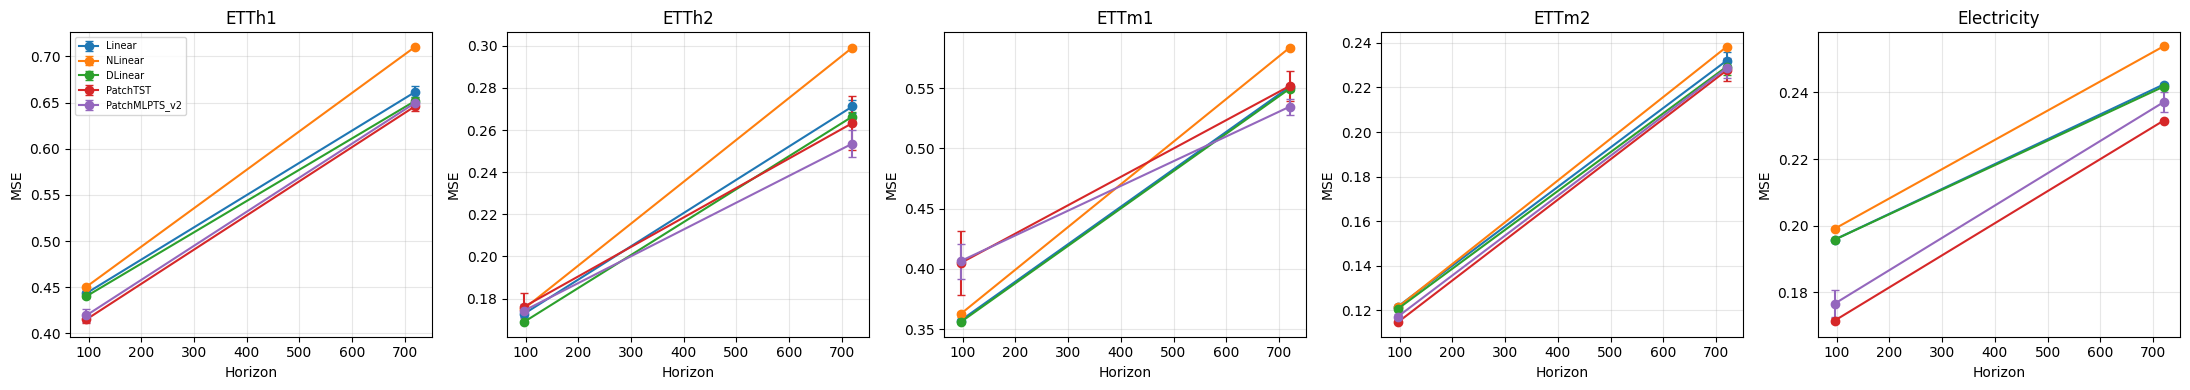

In [5]:
datasets_order = ["ETTh1", "ETTh2", "ETTm1", "ETTm2", "Electricity"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for ax, ds in zip(axes, datasets_order):
    sub = df_summary[df_summary["dataset"] == ds].sort_values("horizon")
    for model_name in ["Linear", "NLinear", "DLinear", "PatchTST", "PatchMLPTS_v2"]:
        m = sub[sub["model"] == model_name]
        ax.errorbar(m["horizon"], m["MSE_mean"], yerr=m["MSE_std"], marker="o",
                    label=model_name, capsize=3)
    ax.set_title(ds)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("MSE")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig("figure1_main_benchmark.png", dpi=300, bbox_inches="tight")
plt.savefig("figure1_main_benchmark.pdf", bbox_inches="tight")
plt.show()

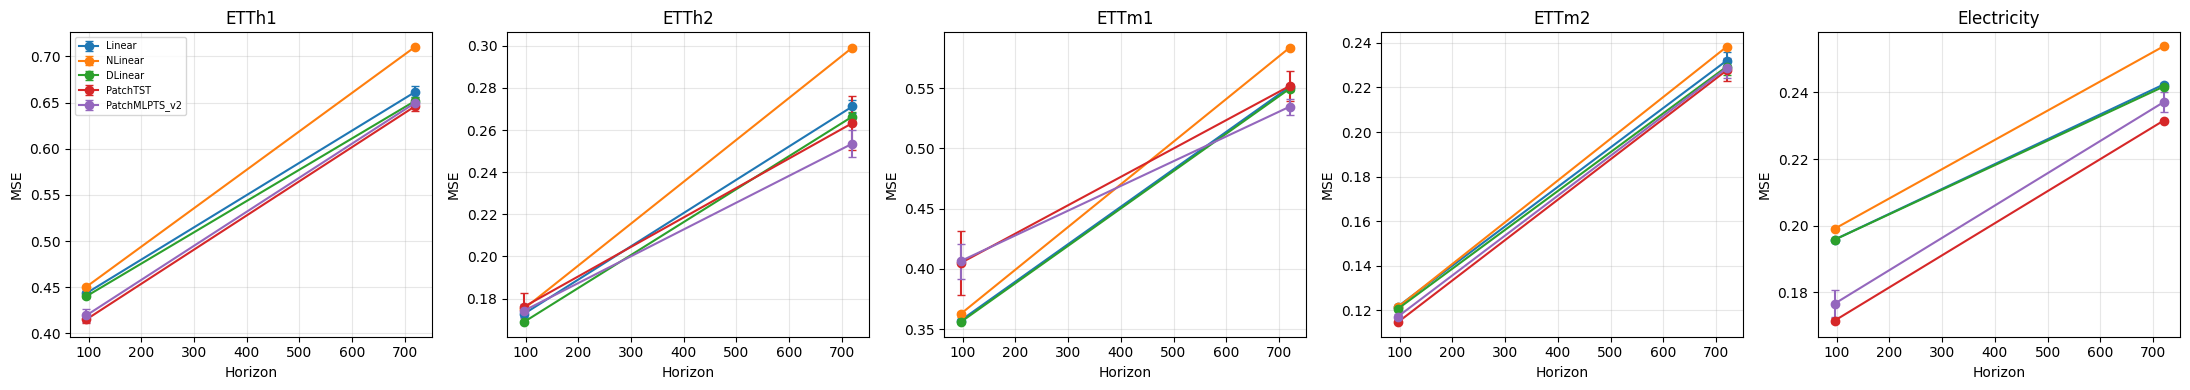

In [6]:
datasets_order = ["ETTh1", "ETTh2", "ETTm1", "ETTm2", "Electricity"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for ax, ds in zip(axes, datasets_order):
    sub = df_summary[df_summary["dataset"] == ds].sort_values("horizon")
    for model_name in ["Linear", "NLinear", "DLinear", "PatchTST", "PatchMLPTS_v2"]:
        m = sub[sub["model"] == model_name]
        ax.errorbar(m["horizon"], m["MSE_mean"], yerr=m["MSE_std"], marker="o",
                    label=model_name, capsize=3)
    ax.set_title(ds)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("MSE")
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig("figure1_main_benchmark.png", dpi=300, bbox_inches="tight")
plt.savefig("figure1_main_benchmark.pdf", bbox_inches="tight")
plt.show()

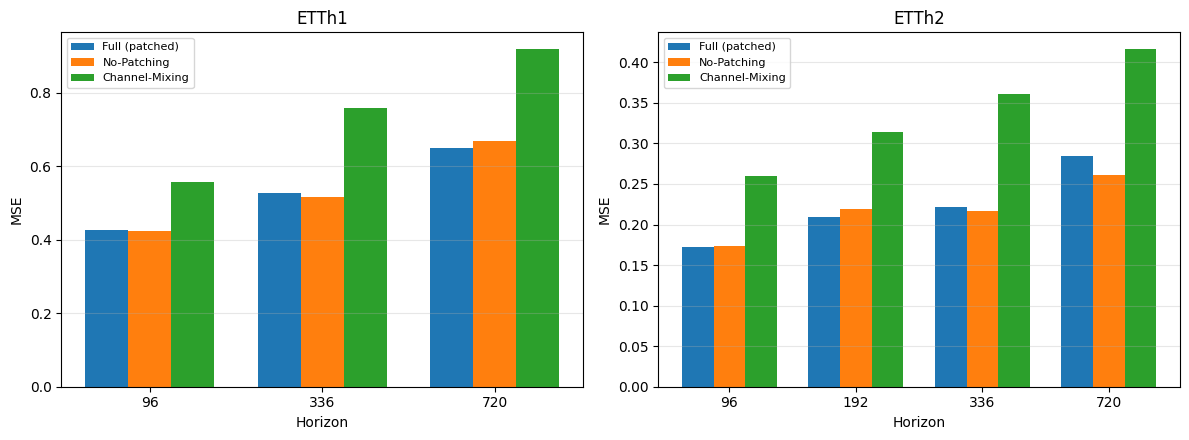

In [8]:
ablation_data = {
    "ETTh1": {96: (0.4272, 0.4246, 0.5566),
              336: (0.5273, 0.5154, 0.7584), 720: (0.6498, 0.6698, 0.9187)},
    "ETTh2": {96: (0.1727, 0.1730, 0.2600), 192: (0.2089, 0.2187, 0.3143),
              336: (0.2211, 0.2164, 0.3615), 720: (0.2849, 0.2606, 0.4162)},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, ds in zip(axes, ["ETTh1", "ETTh2"]):
    horizons = sorted(ablation_data[ds].keys())
    full = [ablation_data[ds][h][0] for h in horizons]
    nopatch = [ablation_data[ds][h][1] for h in horizons]
    chmix = [ablation_data[ds][h][2] for h in horizons]

    x = range(len(horizons))
    width = 0.25
    ax.bar([i - width for i in x], full, width, label="Full (patched)")
    ax.bar(x, nopatch, width, label="No-Patching")
    ax.bar([i + width for i in x], chmix, width, label="Channel-Mixing")
    ax.set_xticks(list(x))
    ax.set_xticklabels(horizons)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("MSE")
    ax.set_title(ds)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figure2_ablation.png", dpi=300, bbox_inches="tight")
plt.savefig("figure2_ablation.pdf", bbox_inches="tight")
plt.show()

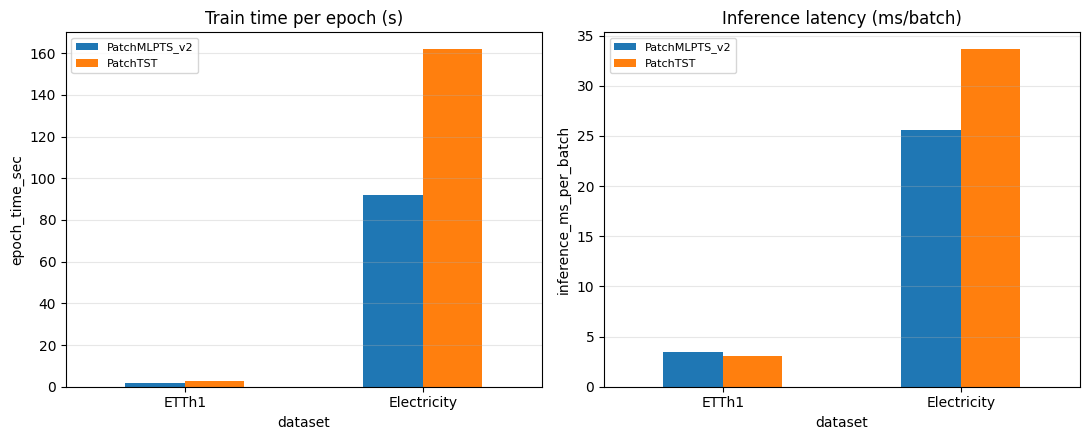

In [10]:
df_eff = pd.read_csv("/kaggle/input/datasets/vedantjadhavv/seed-results/efficiency_v2_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric, title in zip(axes, ["epoch_time_sec", "inference_ms_per_batch"],
                              ["Train time per epoch (s)", "Inference latency (ms/batch)"]):
    pivot = df_eff.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figure3_efficiency.png", dpi=300, bbox_inches="tight")
plt.savefig("figure3_efficiency.pdf", bbox_inches="tight")
plt.show()

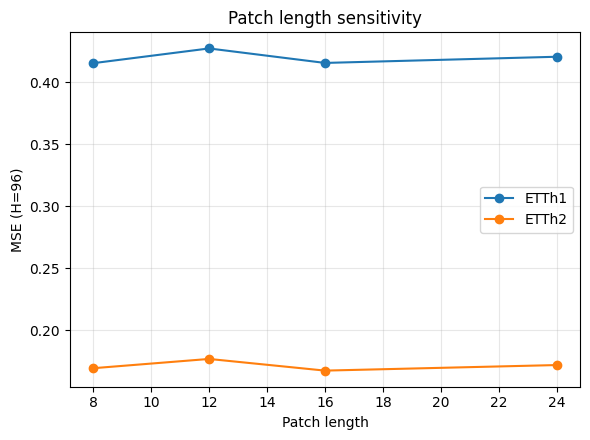

In [11]:
df_patch = pd.read_csv("/kaggle/input/datasets/vedantjadhavv/seed-results/patch_size_ablation.csv")

fig, ax = plt.subplots(figsize=(6, 4.5))
for ds in df_patch["dataset"].unique():
    sub = df_patch[df_patch["dataset"] == ds].sort_values("patch_len")
    ax.plot(sub["patch_len"], sub["MSE"], marker="o", label=ds)

ax.set_xlabel("Patch length")
ax.set_ylabel("MSE (H=96)")
ax.set_title("Patch length sensitivity")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure4_patch_sensitivity.png", dpi=300, bbox_inches="tight")
plt.savefig("figure4_patch_sensitivity.pdf", bbox_inches="tight")
plt.show()